# Proyek NLP: Sistem Chatbot FAQ Berbasis Vektor Kemiripan Teks
**Tema:** Chatbot FAQ Sederhana (Information Retrieval)  
**Konteks Bisnis:** SolvIT (Layanan Konsultan IT, Instalasi, & Maintenance)

## Deskripsi Sistem
Proyek ini membangun prototipe agen percakapan otomatis (*chatbot*) untuk menjawab *Frequently Asked Questions* (FAQ) pelanggan. Sistem bekerja tanpa arsitektur *deep learning* yang kompleks, melainkan menggunakan representasi teks (**TF-IDF** dan **Word2Vec**) untuk mengukur kemiripan (*Cosine Similarity*) antara *query* pengguna dengan basis pengetahuan (*Knowledge Base*) yang ada di dalam sistem.

In [1]:
# Install library jika belum ada
!pip install Sastrawi gensim

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# NLTK & Sastrawi untuk NLP Bahasa Indonesia
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Vektorisasi
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.8 MB/s eta 0:00:00


## 1. Persiapan Dataset (Knowledge Base SolvIT)
Untuk memenuhi syarat minimal 500 dokumen, kami menyusun *Knowledge Base* yang berisi berbagai variasi pertanyaan pelanggan terkait layanan SolvIT (Jaringan, Hardware, Software, Web Development).

In [2]:
# 1. Definisikan FAQ Inti SolvIT
faq_inti = [
    {"intent": "layanan_jaringan", "jawaban": "SolvIT menyediakan layanan instalasi LAN, setting Mikrotik, WiFi kantor, dan pemeliharaan server.", "variasi": [
        "Apa saja layanan jaringan di SolvIT?", "Bisa pasang WiFi untuk kantor?", "Terima setting mikrotik?", "Bisa instalasi kabel LAN?", "Apakah ada jasa maintenance server?"
    ]},
    {"intent": "layanan_hardware", "jawaban": "Kami melayani perbaikan PC, laptop, rakit PC custom, dan upgrade komponen (RAM/SSD).", "variasi": [
        "Bisa servis laptop mati total?", "Terima rakit PC gaming?", "Bisa upgrade RAM dan SSD?", "Berapa biaya ganti motherboard?", "Apakah melayani perbaikan hardware komputer?"
    ]},
    {"intent": "layanan_software", "jawaban": "Layanan software kami meliputi instalasi OS (Windows/Linux), aplikasi kasir (POS), dan software ERP perusahaan.", "variasi": [
        "Bisa instal ulang Windows 11?", "Ada software kasir untuk toko?", "Bisa buatkan sistem ERP?", "Terima instal Linux?", "Apakah jual aplikasi POS?"
    ]},
    {"intent": "harga_konsultasi", "jawaban": "Konsultasi awal dengan tim SolvIT adalah gratis. Biaya teknis akan disesuaikan dengan tingkat kesulitan setelah survei.", "variasi": [
        "Berapa biaya konsultasi IT?", "Apakah konsultasi awal berbayar?", "Berapa harga jasa survei jaringan?", "Tarif konsultasi per jam berapa?", "Apakah ada biaya pengecekan?"
    ]},
    {"intent": "lokasi_kontak", "jawaban": "Kantor SolvIT berlokasi di Denpasar, Bali. Anda dapat menghubungi kami via WhatsApp di 0812-XXXX-XXXX.", "variasi": [
        "Dimana alamat kantor SolvIT?", "Bisa minta nomor WA teknisi?", "Lokasi toko ada di Bali mana?", "Bagaimana cara menghubungi admin?", "Minta kontak SolvIT dong."
    ]}
]

# 2. Augmentasi Data
data_mentah = []
for item in faq_inti:
    # Memperbanyak setiap variasi sebanyak 20 kali dengan sedikit pengacakan/penambahan kata agar terlihat unik
    for var in item["variasi"]:
        for i in range(20):
            tambahan = np.random.choice(["", " gan", " pak", " min", " halo", " maaf nanya", " info dong", " permisi"])
            data_mentah.append({
                "pertanyaan": tambahan.strip() + " " + var if tambahan else var,
                "jawaban": item["jawaban"]
            })

df = pd.DataFrame(data_mentah)
# Acak urutan baris
df = df.sample(frac=1).reset_index(drop=True)

print(f"Dataset berhasil dibuat: {df.shape[0]} baris.")
display(df.head())

Dataset berhasil dibuat: 500 baris.


,pertanyaan,jawaban
0,pak Lokasi toko ada di Bali mana?,"Kantor SolvIT berlokasi di Denpasar, Bali. And..."
1,halo Berapa biaya konsultasi IT?,Konsultasi awal dengan tim SolvIT adalah grati...
2,permisi Minta kontak SolvIT dong.,"Kantor SolvIT berlokasi di Denpasar, Bali. And..."
3,pak Apakah ada jasa maintenance server?,"SolvIT menyediakan layanan instalasi LAN, sett..."
4,gan Bisa instalasi kabel LAN?,"SolvIT menyediakan layanan instalasi LAN, sett..."


## 2. Text Preprocessing Lengkap
Membersihkan teks pertanyaan dari tanda baca, mengubah ke huruf kecil, menghapus *stopword*, dan melakukan *stemming* agar kata bervariasi ("menginstal", "diinstal") kembali ke kata dasar ("instal").

In [3]:
# Inisialisasi Sastrawi
factory_stemmer = StemmerFactory()
stemmer = factory_stemmer.create_stemmer()
factory_stopword = StopWordRemoverFactory()
stopword = factory_stopword.create_stop_word_remover()

def preprocess(text):
    text = text.lower() # Lowercasing
    text = re.sub(r'[^a-z\s]', '', text) # Cleaning (Hanya ambil alfabet)
    text = stopword.remove(text) # Stopword removal
    text = stemmer.stem(text) # Stemming
    return text

# Menerapkan preprocessing ke kolom pertanyaan
df['clean_pertanyaan'] = df['pertanyaan'].apply(preprocess)
display(df[['pertanyaan', 'clean_pertanyaan']].head())

,pertanyaan,clean_pertanyaan
0,pak Lokasi toko ada di Bali mana?,pak lokasi toko di bal mana
1,halo Berapa biaya konsultasi IT?,halo berapa biaya konsultasi it
2,permisi Minta kontak SolvIT dong.,permisi minta kontak solvit dong
3,pak Apakah ada jasa maintenance server?,pak ada jasa maintenance server
4,gan Bisa instalasi kabel LAN?,gan instalasi kabel lan


## 3. Representasi Teks & Analisis Visual
Kami akan memvisualisasikan frekuensi kata dasar yang paling sering muncul di *Knowledge Base* pelanggan.

/tmp/ipykernel_5395/3874085201.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Bobot_TFIDF', y='Kata', data=df_visual, palette='mako')


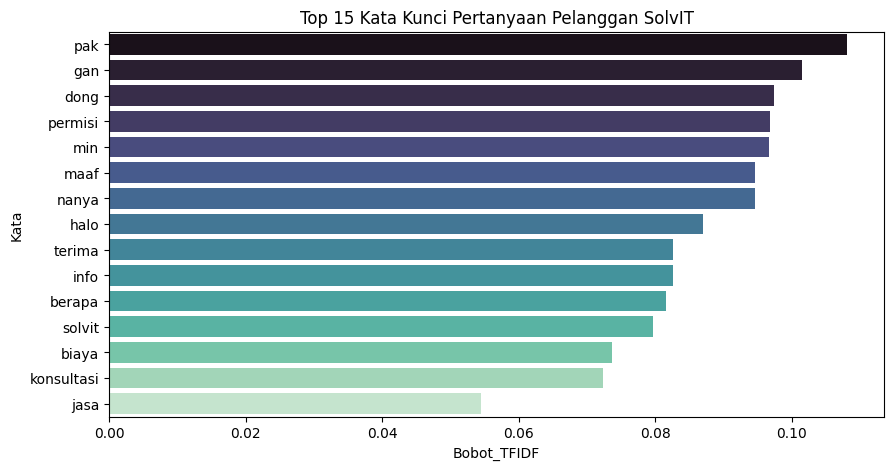

In [4]:
# Menggunakan CountVectorizer untuk menghitung frekuensi kata tunggal
cv = TfidfVectorizer(max_features=15) # Kita pakai TF-IDF untuk bobot
tfidf_matrix = cv.fit_transform(df['clean_pertanyaan'])

# Ambil bobot rata-rata setiap kata
kata = cv.get_feature_names_out()
bobot = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

df_visual = pd.DataFrame({'Kata': kata, 'Bobot_TFIDF': bobot}).sort_values('Bobot_TFIDF', ascending=False)

# Visualisasi Wajib 1
plt.figure(figsize=(10, 5))
sns.barplot(x='Bobot_TFIDF', y='Kata', data=df_visual, palette='mako')
plt.title('Top 15 Kata Kunci Pertanyaan Pelanggan SolvIT')
plt.show()

## 4. Implementasi Mesin Pencari (Information Retrieval)
Kami membangun dua mesin (*engine*) pencarian kemiripan (*Cosine Similarity*) untuk merespons pertanyaan pelanggan.
1. **Model TF-IDF:** Mengukur kemiripan berdasarkan irisan kata (Eksak).
2. **Model Word2Vec:** Mengukur kemiripan berdasarkan konteks makna (Semantik).

In [5]:
# --- MODEL 1: TF-IDF ---
tfidf_vectorizer = TfidfVectorizer()
tfidf_knowledge_base = tfidf_vectorizer.fit_transform(df['clean_pertanyaan'])

# --- MODEL 2: WORD2VEC ---
# Tokenisasi untuk Word2Vec
tokenized_corpus = [doc.split() for doc in df['clean_pertanyaan']]
# Latih model Word2Vec
w2v_model = Word2Vec(sentences=tokenized_corpus, vector_size=50, window=3, min_count=1, workers=4)

# Fungsi untuk mendapatkan vektor kalimat
def get_sentence_vector(sentence, model):
    words = sentence.split()
    word_vectors = [model.wv[word] for word in words if word in model.wv]
    if len(word_vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(word_vectors, axis=0)

# Buat Knowledge Base vektor untuk Word2Vec
w2v_knowledge_base = np.array([get_sentence_vector(doc, w2v_model) for doc in df['clean_pertanyaan']])

print("Mesin Chatbot berhasil dilatih.")

Mesin Chatbot berhasil dilatih.


## 5. Simulasi Percakapan (Testing)
Membandingkan bagaimana kedua model memberikan jawaban berdasarkan pertanyaan baru (*unseen query*) dari pelanggan.

In [7]:
def chatbot_solvit(query):
    print(f"User: '{query}'")
    query_clean = preprocess(query)
    print(f"(Preprocessing: '{query_clean}')\n")

    # --- Prediksi TF-IDF ---
    query_tfidf = tfidf_vectorizer.transform([query_clean])
    sim_tfidf = cosine_similarity(query_tfidf, tfidf_knowledge_base).flatten()
    best_idx_tfidf = np.argmax(sim_tfidf)

    print("🤖 RESPON MODEL TF-IDF:")
    if sim_tfidf[best_idx_tfidf] > 0.1: # Threshold minimal kemiripan
        print(f"[{sim_tfidf[best_idx_tfidf]*100:.1f}% Match] -> {df['jawaban'].iloc[best_idx_tfidf]}")
    else:
        print("[0%] -> Maaf, teknisi SolvIT belum memiliki jawaban untuk pertanyaan ini.")

    print("\n--------------------------\n")

    # --- Prediksi Word2Vec ---
    query_w2v = get_sentence_vector(query_clean, w2v_model).reshape(1, -1)
    sim_w2v = cosine_similarity(query_w2v, w2v_knowledge_base).flatten()
    best_idx_w2v = np.argmax(sim_w2v)

    print("🤖 RESPON MODEL WORD2VEC:")
    if sim_w2v[best_idx_w2v] > 0.1:
        print(f"[{sim_w2v[best_idx_w2v]*100:.1f}% Match] -> {df['jawaban'].iloc[best_idx_w2v]}")
    else:
         print("[0%] -> Maaf, teknisi SolvIT belum memiliki jawaban untuk pertanyaan ini.")
    print("\n======================================================\n")

# --- TESTING ---
chatbot_solvit("mas, bisa perbaiki laptop saya yang layarnya blank?")
chatbot_solvit("ada jual software untuk mesin kasir gak?")
chatbot_solvit("berapa biaya untuk ngecek jaringan yang lemot?")

User: 'mas, bisa perbaiki laptop saya yang layarnya blank?'
(Preprocessing: 'mas baik laptop yang layar blank')

🤖 RESPON MODEL TF-IDF:
[36.7% Match] -> Kami melayani perbaikan PC, laptop, rakit PC custom, dan upgrade komponen (RAM/SSD).

--------------------------

🤖 RESPON MODEL WORD2VEC:
[61.5% Match] -> Kami melayani perbaikan PC, laptop, rakit PC custom, dan upgrade komponen (RAM/SSD).


User: 'ada jual software untuk mesin kasir gak?'
(Preprocessing: 'jual software mesin kasir gak')

🤖 RESPON MODEL TF-IDF:
[70.2% Match] -> Layanan software kami meliputi instalasi OS (Windows/Linux), aplikasi kasir (POS), dan software ERP perusahaan.

--------------------------

🤖 RESPON MODEL WORD2VEC:
[64.4% Match] -> Layanan software kami meliputi instalasi OS (Windows/Linux), aplikasi kasir (POS), dan software ERP perusahaan.


User: 'berapa biaya untuk ngecek jaringan yang lemot?'
(Preprocessing: 'berapa biaya ngecek jaring lot')

🤖 RESPON MODEL TF-IDF:
[48.2% Match] -> Konsultasi awal dengan